**Introduction**

* *Brain tumor detection from MRI scans is an important problem in medical imaging, as early and accurate diagnosis can significantly improve treatment outcomes. Manual analysis of MRI images is time-consuming and requires expert radiologists, which motivates the use of automated deep learning–based approaches.*

* *In this notebook, we develop a brain tumor classification system using convolutional neural networks (CNNs) and transfer learning. The goal is to classify brain MRI images into tumor and non-tumor categories based on visual features extracted from the scans. We leverage a pre-trained MobileNetV2 model, which has been trained on the ImageNet dataset, and fine-tune it for the brain tumor detection task. Transfer learning allows us to achieve good performance even with a limited amount of medical imaging data.*

The notebook covers the complete pipeline, including:

* Loading and exploring the brain tumor dataset

* Performing basic exploratory data analysis (EDA)

* Image preprocessing and resizing for CNN input

* Building a deep learning model using MobileNetV2

* Training and evaluating the model on test data

* Assessing performance using metrics such as accuracy, confusion matrix, and classification report

*This notebook demonstrates how deep learning and transfer learning techniques can be effectively applied to medical image classification tasks, providing a practical and scalable approach for automated brain tumor detection.*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.io import imread
from sklearn.model_selection import train_test_split
import keras
from tensorflow.keras.models import Sequential
from keras.applications import MobileNetV2
from keras.layers import Dense
from tensorflow.keras.preprocessing import image
import pandas as pd
import numpy as np
import os

In [ ]:
brain_df = pd.read_csv('/content/Brain Tumor.csv',usecols=[0,1])
brain_df.head()

,Image,Class
0,Image1,0
1,Image2,0
2,Image3,1
3,Image4,1
4,Image5,0


In [ ]:
brain_df.isna().sum()

,0
Image,0
Class,0


In [ ]:
brain_df['Class'].value_counts()

,count
Class,
0,2079
1,1683


<Axes: ylabel='count'>

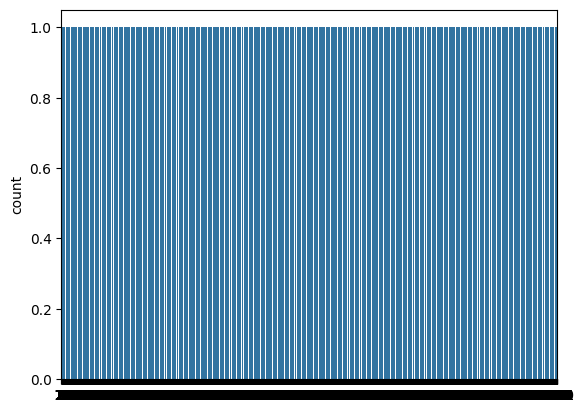

In [ ]:
sns.countplot(brain_df['Class'])

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/Brain Scans.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_list = []
base_path = '/content/drive/MyDrive/Brain Tumor'
for entry in os.listdir(base_path):
    path_list.append( os.path.join(base_path,entry))

In [ ]:
pathes_dict={os.path.splitext(os.path.basename(x))[0]: x for x in path_list}
brain_df['pathes'] = brain_df['Image'].map(pathes_dict.get)

In [ ]:
brain_df.head()

,Image,Class,pathes
0,Image1,0,/content/drive/MyDrive/Brain Tumor/Image1.jpg
1,Image2,0,/content/drive/MyDrive/Brain Tumor/Image2.jpg
2,Image3,1,/content/drive/MyDrive/Brain Tumor/Image3.jpg
3,Image4,1,/content/drive/MyDrive/Brain Tumor/Image4.jpg
4,Image5,0,/content/drive/MyDrive/Brain Tumor/Image5.jpg


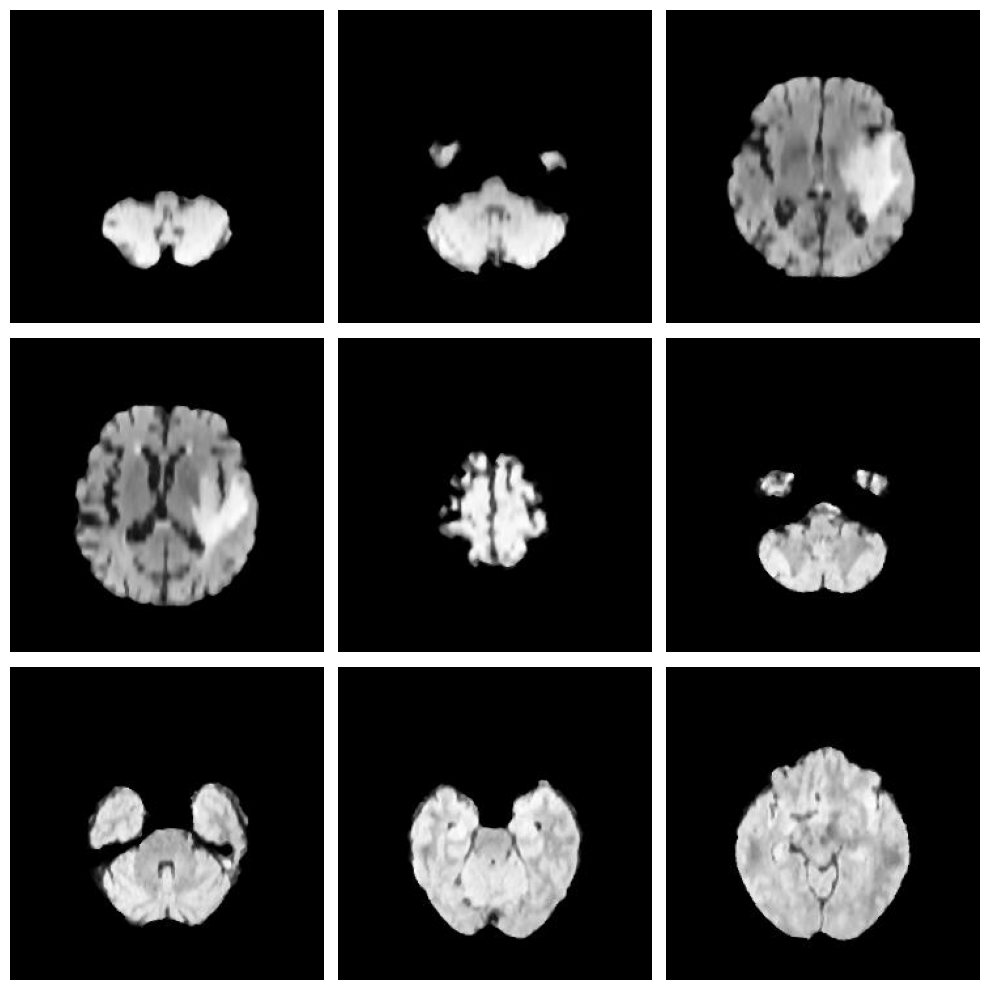

In [ ]:
#for x in range (0 ,9):
 #   img = imread(brain_df['pathes'][x])
  #  plt.imshow(img)
   # plt.subplot(3,3,x+1)

import matplotlib.pyplot as plt
from matplotlib.image import imread

plt.figure(figsize=(10, 10))  # Adjust figure size for better spacing

for x in range(9):
    plt.subplot(3, 3, x + 1)           # Create a 3x3 grid
    img = imread(brain_df['pathes'][x]) # Read image
    plt.imshow(img)
    plt.axis('off')                     # Hide axes for cleaner display

plt.tight_layout()                      # Adjust spacing between subplots
plt.show()

In [ ]:
from PIL.Image import open
brain_df['pixels']=brain_df['pathes'].map(lambda x:np.asarray(open(x).resize((224,224))))

In [ ]:
brain_df.head()

,Image,Class,pathes,pixels
0,Image1,0,/content/drive/MyDrive/Brain Tumor/Image1.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
1,Image2,0,/content/drive/MyDrive/Brain Tumor/Image2.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
2,Image3,1,/content/drive/MyDrive/Brain Tumor/Image3.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
3,Image4,1,/content/drive/MyDrive/Brain Tumor/Image4.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
4,Image5,0,/content/drive/MyDrive/Brain Tumor/Image5.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."


In [ ]:
image_list = []
for i in range(0,len(brain_df)):
    # load image
    brain_img = brain_df['pixels'][i].astype(np.float32)
    img_array = image.img_to_array(brain_img)
     # append to list of all images
    image_list.append(keras.applications.mobilenet_v2.preprocess_input(img_array))

# convert image list to single array
# Our feature
X = np.array(image_list)

# print shape of X
print(X.shape)

(3762, 224, 224, 3)


In [ ]:
y = np.array(brain_df.Class)

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y
                                                 ,test_size=0.2
                                                ,random_state=0)


print('The shape of the X_train :'+' '+str(X_train.shape))
print('The size of the X_train :'+' '+str(X_train.shape[0]))
print('The shape of the X_test :'+' '+str(X_test.shape))
print('The size of the X_test:'+' '+str(X_test.shape[0]))

The shape of the X_train : (3009, 224, 224, 3)
The size of the X_train : 3009
The shape of the X_test : (753, 224, 224, 3)
The size of the X_test: 753


In [ ]:
num_classes = 1
model = Sequential()
model.add(MobileNetV2(input_shape=(224, 224, 3),weights="imagenet"
                             ,include_top=False))
model.add(keras.layers.GlobalAveragePooling2D())
model.add( Dense(num_classes, activation='sigmoid',name='preds'))
model.layers[0].trainable= False
# show model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preds (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(optimizer = 'adam', loss = 'hinge', metrics = ['accuracy'])


# mock-train the model
training_log = model.fit(
    X_train,
    y_train,
    epochs=5,
    verbose=1,
    validation_data=(X_test, y_test)
)
model.save("model_brain.h5")
print("Saved model to disk")

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.8933 - loss: 0.7096 - val_accuracy: 0.8858 - val_loss: 0.6755
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9007 - loss: 0.6836 - val_accuracy: 0.8725 - val_loss: 0.6706
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9084 - loss: 0.6736 - val_accuracy: 0.8845 - val_loss: 0.6667
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9139 - loss: 0.6718 - val_accuracy: 0.8938 - val_loss: 0.6620
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9189 - loss: 0.6623 - val_accuracy: 0.8845 - val_loss: 0.6589


Saved model to disk


In [ ]:
pretrained_cnn = keras.models.load_model('./model_brain.h5')

# evaluate model on holdout set
eval_score = pretrained_cnn.evaluate(X_test,y_test)
# print loss score
print('Eval loss:',eval_score[0])
# print accuracy score
print('Eval accuracy:',eval_score[1] )

24/24 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8956 - loss: 0.6520
Eval loss: 0.6589112281799316
Eval accuracy: 0.8844621777534485


In [ ]:
y_pred = (pretrained_cnn.predict(X_test) > 0.5).astype("int32")

24/24 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
target_classes = ['No Tumor','Tumor']
classification_report(y_test , y_pred , output_dict = True
                      , target_names=target_classes)

{'No Tumor': {'precision': 0.8699763593380615,
  'recall': 0.92,
  'f1-score': 0.8942891859052248,
  'support': 400.0},
 'Tumor': {'precision': 0.9030303030303031,
  'recall': 0.8441926345609065,
  'f1-score': 0.8726207906295754,
  'support': 353.0},
 'accuracy': 0.8844621513944223,
 'macro avg': {'precision': 0.8865033311841823,
  'recall': 0.8820963172804532,
  'f1-score': 0.8834549882674001,
  'support': 753.0},
 'weighted avg': {'precision': 0.8854717672044112,
  'recall': 0.8844621513944223,
  'f1-score': 0.8841312263669722,
  'support': 753.0}}

In [ ]:
confusion_matrix(y_test , y_pred )

array([[368,  32],
       [ 55, 298]])

In [ ]:
# Predict probabilities
y_prob = pretrained_cnn.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype("int32")

24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step


In [ ]:
# Classification Report (Precision, Recall, F1-score)

from sklearn.metrics import classification_report

target_classes = ['No Tumor', 'Tumor']

print(classification_report(
    y_test,
    y_pred,
    target_names=target_classes
))

              precision    recall  f1-score   support

    No Tumor       0.87      0.92      0.89       400
       Tumor       0.90      0.84      0.87       353

    accuracy                           0.88       753
   macro avg       0.89      0.88      0.88       753
weighted avg       0.89      0.88      0.88       753



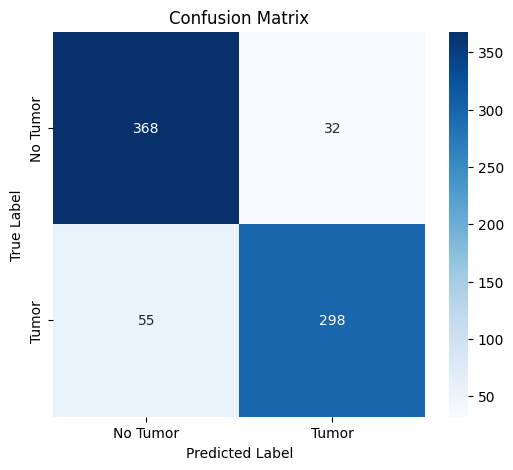

In [ ]:
# confusion matrix (Heat Map)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_classes,
    yticklabels=target_classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

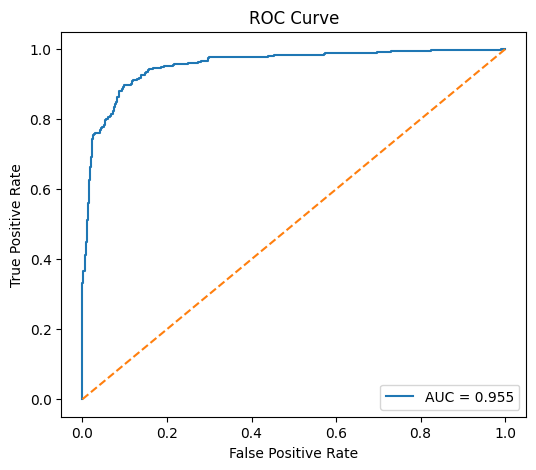

In [ ]:
# ROC Curve & AUC Score
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


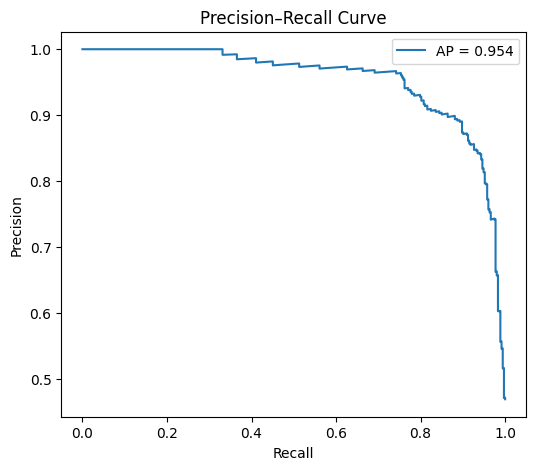

In [ ]:
# Precision Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AP = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.show()


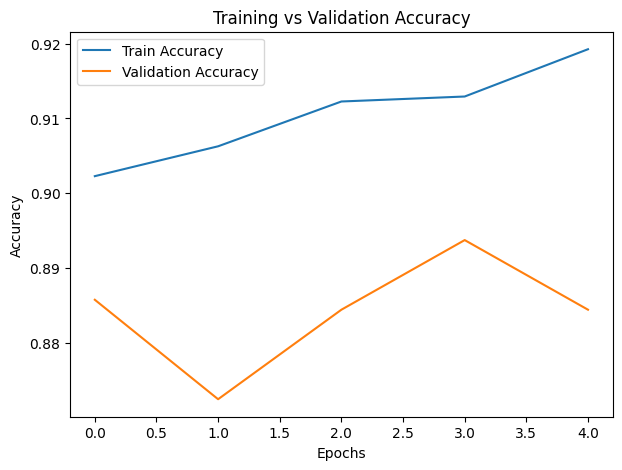

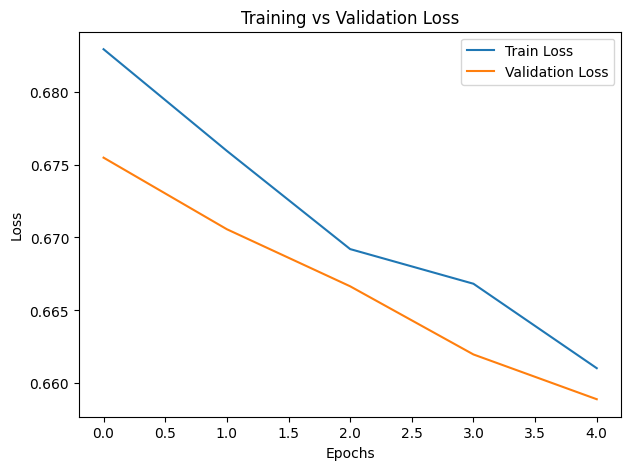

In [ ]:
#Training vs Validation Accuracy & Loss

# Accuracy
plt.figure(figsize=(7,5))
plt.plot(training_log.history['accuracy'], label='Train Accuracy')
plt.plot(training_log.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(7,5))
plt.plot(training_log.history['loss'], label='Train Loss')
plt.plot(training_log.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()




In [ ]:
#Summary Table

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

pd.DataFrame(metrics, index=["Score"])


,Accuracy,Precision,Recall,F1 Score
Score,0.884462,0.90303,0.844193,0.872621
